# US Accidents Exploratory Data Analysis

TODO - talk about the dataset (source, what it contains, how it will be useful)

Kaggle

informaiton about accidents

can use useful to prevent accidents

This dataset does not contain data about New York

In [1]:
import numpy as np
import pandas as pd

# Data Preparation and cleaning

- Load the file using pandas
- Look at some information about the data  & the columns
- Fix any missing or incorrect values

In [2]:
Data = pd.read_csv("/content/US_Accidents_May19_Migrated Data.csv")

In [3]:
Data.head()

,Airport_Code,Amenity,Astronomical_Twilight,Bump,Calculation1,City,Civil_Twilight,count of Bump,Count of Crossing,count Traffic Signal,...,Humidity(%),Number of Records,Precipitation(in),Pressure(in),Records,Start_Lat,Start_Lng,TMC,Wind_Chill(F),Wind_Speed(mph)
0,NaN,False,Day,False,Remaining,Garnet Valley,Day,0,0,0,...,NaN,1.0,NaN,NaN,1.0,39.852940,-75.461739,201.0,NaN,NaN
1,KDWH,False,Day,False,Remaining,Spring,Day,0,0,0,...,82.0,1.0,NaN,30.02,1.0,30.159246,-95.510826,201.0,NaN,5.8
2,KDSM,False,Day,False,Remaining,West des Moines,Day,0,0,0,...,79.0,1.0,NaN,30.04,1.0,41.586887,-93.806496,201.0,34.3,11.5
3,KCPS,False,Day,False,Remaining,Saint Louis,Day,0,0,0,...,84.0,1.0,NaN,30.10,1.0,38.634579,-90.186806,201.0,NaN,12.7
4,KXBP,False,Day,False,Remaining,Springtown,Day,0,0,0,...,96.0,1.0,NaN,29.95,1.0,32.930958,-97.641068,201.0,NaN,5.8


In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airport_Code           13149 non-null  object 
 1   Amenity                13501 non-null  bool   
 2   Astronomical_Twilight  13498 non-null  object 
 3   Bump                   13501 non-null  bool   
 4   Calculation1           13501 non-null  object 
 5   City                   13499 non-null  object 
 6   Civil_Twilight         13498 non-null  object 
 7   count of Bump          13501 non-null  int64  
 8   Count of Crossing      13501 non-null  int64  
 9   count Traffic Signal   13501 non-null  int64  
 10  Country                13501 non-null  object 
 11  County                 13501 non-null  object 
 12  Crossing               13501 non-null  bool   
 13  Description            13501 non-null  object 
 14  End_Lat                1116 non-null   float64
 15  En

In [5]:
Data.isnull().sum()

,0
Airport_Code,352
Amenity,0
Astronomical_Twilight,3
Bump,0
Calculation1,0
City,2
Civil_Twilight,3
count of Bump,0
Count of Crossing,0
count Traffic Signal,0


In [6]:
Data.columns

Index(['Airport_Code', 'Amenity', 'Astronomical_Twilight', 'Bump',
       'Calculation1', 'City', 'Civil_Twilight', 'count of Bump',
       'Count of Crossing', 'count Traffic Signal', 'Country', 'County',
       'Crossing', 'Description', 'End_Lat', 'End_Lng', 'End_Time', 'Give_Way',
       'ID', 'Junction', 'Nautical_Twilight', 'No_Exit', 'Number', 'Railway',
       'Roundabout', 'Severity', 'Side', 'Source', 'Start_Time', 'State',
       'Station', 'Stop', 'Street', 'Sunrise_Sunset', 'Temperature(F)',
       'Timezone', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Visibility(mi)', 'Weather_Condition', 'Weather_Timestamp',
       'Wind_Direction', 'Zipcode', 'Count of accidents', 'count of county',
       'Distance(mi)', 'Humidity(%)', 'Number of Records', 'Precipitation(in)',
       'Pressure(in)', 'Records', 'Start_Lat', 'Start_Lng', 'TMC',
       'Wind_Chill(F)', 'Wind_Speed(mph)'],
      dtype='object')

In [7]:
Data.shape

(13501, 57)

In [8]:
Data.describe()

,count of Bump,Count of Crossing,count Traffic Signal,End_Lat,End_Lng,Number,Severity,Temperature(F),Visibility(mi),Count of accidents,...,Humidity(%),Number of Records,Precipitation(in),Pressure(in),Records,Start_Lat,Start_Lng,TMC,Wind_Chill(F),Wind_Speed(mph)
count,13501.0,13501.0,13501.0,1116.000000,1116.000000,11964.000000,13501.000000,12873.000000,12828.000000,13500.000000,...,12868.000000,13500.0,1443.000000,12894.000000,13500.000000,13500.000000,13500.000000,12385.000000,2538.000000,8233.000000
mean,0.0,0.0,0.0,35.080936,-88.447423,5144.884988,2.013480,57.390321,8.998269,0.999852,...,69.661486,1.0,0.053243,30.073928,0.999852,35.399900,-91.438309,204.042309,25.442199,9.072732
std,0.0,0.0,0.0,5.437009,6.926307,6643.262586,0.168115,19.559342,3.079578,0.012171,...,21.280146,0.0,0.391290,0.218861,0.012171,5.062190,11.937469,13.889107,13.488760,4.697329
min,0.0,0.0,0.0,25.455820,-102.255394,1.000000,0.000000,-20.000000,0.100000,0.000000,...,9.000000,1.0,0.000000,29.120000,0.000000,25.174532,-124.154404,200.000000,-47.300000,1.200000
25%,0.0,0.0,0.0,30.275591,-95.538365,993.750000,2.000000,44.100000,10.000000,1.000000,...,54.000000,1.0,0.000000,29.950000,1.000000,30.362715,-97.229126,201.000000,18.500000,5.800000
50%,0.0,0.0,0.0,35.164507,-88.057710,2999.500000,2.000000,59.000000,10.000000,1.000000,...,72.000000,1.0,0.010000,30.070000,1.000000,34.680420,-91.119522,201.000000,28.100000,8.100000
75%,0.0,0.0,0.0,41.147033,-80.961787,7114.250000,2.000000,73.000000,10.000000,1.000000,...,88.000000,1.0,0.030000,30.200000,1.000000,40.239424,-82.000690,201.000000,35.400000,11.500000
max,0.0,0.0,0.0,47.321240,-70.673920,106724.000000,4.000000,106.000000,50.000000,1.000000,...,100.000000,1.0,9.990000,31.000000,1.000000,48.906120,-70.184402,406.000000,45.200000,36.800000


In [9]:
numerics = ["int16","int32","int64","float16","float32","float64"]
numeric_data = Data.select_dtypes(include=numerics)
len(numeric_data.columns)

22

In [10]:
 Data.isnull().sum().sort_values(ascending=False)

,0
End_Lng,12385
End_Lat,12385
Precipitation(in),12058
Wind_Chill(F),10963
Wind_Speed(mph),5268
Number,1537
TMC,1116
Weather_Condition,692
Visibility(mi),673
Humidity(%),633


In [11]:
Missing_percentage = Data.isnull().sum().sort_values(ascending=False) / len(Data)
Missing_percentage

,0
End_Lng,0.917339
End_Lat,0.917339
Precipitation(in),0.893119
Wind_Chill(F),0.812014
Wind_Speed(mph),0.390193
Number,0.113843
TMC,0.082661
Weather_Condition,0.051255
Visibility(mi),0.049848
Humidity(%),0.046885


<Axes: >

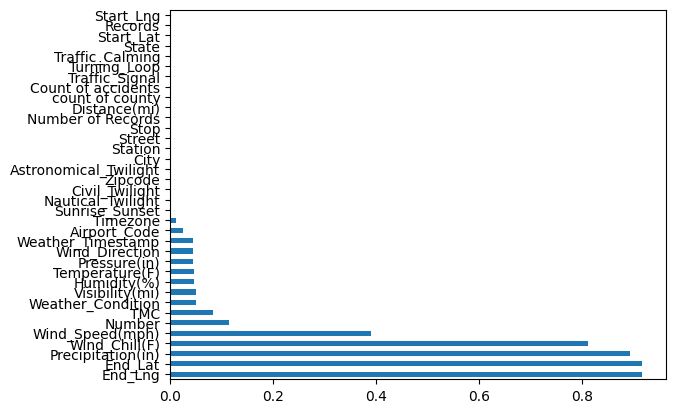

In [12]:
Missing_percentage[Missing_percentage != 0].plot(kind = "barh")

## Ask & answer questions

1. Which 5 states have the highest number of accidents?
2. Among the top 100 cities in number of accidents, which states do they belong to most frequently.
3. What time of the day are accidents most frequent in?
4. Which days of the week have the most accidents?
5. Which months have the most accidents?
6. What is the trend of accidents year over year.


# Top 5 states with highest number of accidents?

In [49]:
# Top 5 states with highest number of accidents?
State_wise_Accidents = Data.State.value_counts()
Top_5_States = State_wise_Accidents.head(5)
print("Top 5 states with the most accidents:")
print(Top_5_States)

Top 5 states with the most accidents:
State
TX    3900
IL    1099
SC     897
CA     788
NC     779
Name: count, dtype: int64


In [15]:
cities_by_Accidents = Data.City.value_counts()
cities_by_Accidents

,count
City,
Houston,1444
Austin,1120
Dallas,574
Baton Rouge,424
Charlotte,405
...,...
Dowelltown,1
Nolensville,1
Lincoln,1


In [36]:
# Top 10 cities with most Accident
cities_by_Accidents[:10]

,count
City,
Houston,1444
Austin,1120
Dallas,574
Baton Rouge,424
Charlotte,405
San Antonio,240
Raleigh,208
Lafayette,204
Omaha,194


<Axes: ylabel='City'>

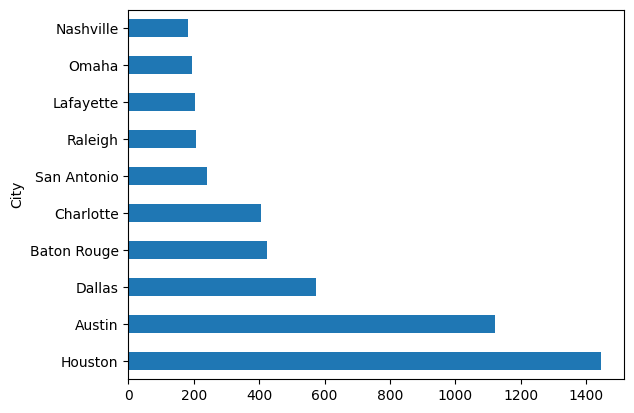

In [17]:
cities_by_Accidents[:10].plot(kind="barh")

In [39]:
# Check if Newyork is present in the column
"New York" in Data.City

False

In [18]:
Data.columns

Index(['Airport_Code', 'Amenity', 'Astronomical_Twilight', 'Bump',
       'Calculation1', 'City', 'Civil_Twilight', 'count of Bump',
       'Count of Crossing', 'count Traffic Signal', 'Country', 'County',
       'Crossing', 'Description', 'End_Lat', 'End_Lng', 'End_Time', 'Give_Way',
       'ID', 'Junction', 'Nautical_Twilight', 'No_Exit', 'Number', 'Railway',
       'Roundabout', 'Severity', 'Side', 'Source', 'Start_Time', 'State',
       'Station', 'Stop', 'Street', 'Sunrise_Sunset', 'Temperature(F)',
       'Timezone', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Visibility(mi)', 'Weather_Condition', 'Weather_Timestamp',
       'Wind_Direction', 'Zipcode', 'Count of accidents', 'count of county',
       'Distance(mi)', 'Humidity(%)', 'Number of Records', 'Precipitation(in)',
       'Pressure(in)', 'Records', 'Start_Lat', 'Start_Lng', 'TMC',
       'Wind_Chill(F)', 'Wind_Speed(mph)'],
      dtype='object')

In [19]:
import seaborn as sns

<Axes: xlabel='count', ylabel='Count'>

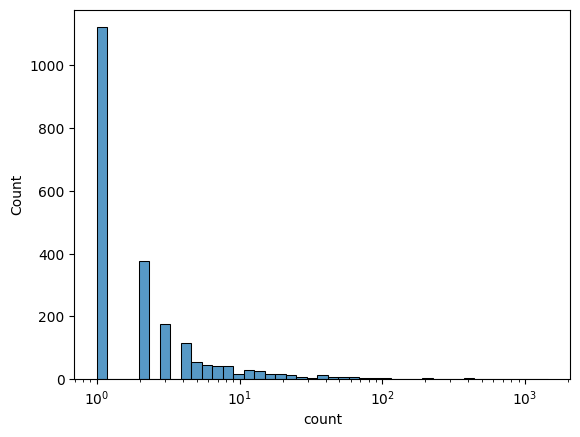

In [20]:
sns.histplot(cities_by_Accidents, log_scale=True)

In [21]:
cities_by_Accidents[cities_by_Accidents == 1]

,count
City,
Bushnell,1
West des Moines,1
Richton Park,1
Braceville,1
Alleman,1
...,...
Dowelltown,1
Nolensville,1
Lincoln,1


In [22]:
Data.Start_Time

,Start_Time
0,7/18/2016 4:55:17 PM
1,8/27/2016 11:17:06 AM
2,11/23/2016 3:03:57 PM
3,9/30/2016 9:06:50 AM
4,8/13/2016 9:18:57 AM
...,...
13496,2/17/2016 5:04:42 PM
13497,1/3/2017 7:47:41 AM
13498,1/3/2017 7:47:41 AM
13499,12/15/2016 3:49:04 PM


In [23]:
# Convert 'Start_Time' column to datetime objects
Data.Start_Time = pd.to_datetime(Data.Start_Time)

<ipython-input-23-2d21e280cc74>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Data.Start_Time = pd.to_datetime(Data.Start_Time)


# What time of the day are accidents most frequent in?

<ipython-input-63-cab6b2e63694>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Data.Start_Time.dt.hour, bins=24, kde=False, norm_hist=True,color='green')


<Axes: xlabel='Start_Time'>

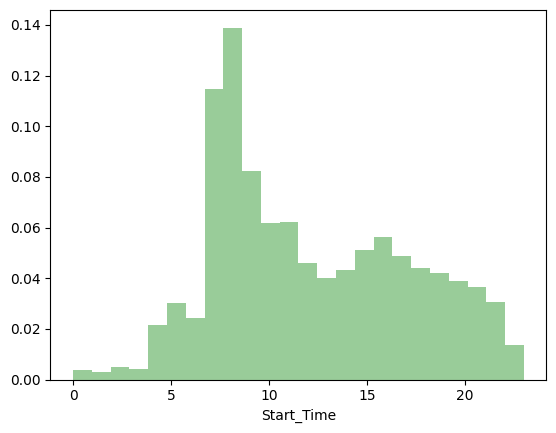

In [63]:
# occurance of Accidents per hour.
sns.distplot(Data.Start_Time.dt.hour, bins=24, kde=False, norm_hist=True,color='green')

*   A high percentage of accidents occur between 7 am to 11 am (probably people in a hurry to get to work)
*   Next higest percentage is 3 pm to 5 pm.



# Which days of the week have the most accidents?

<ipython-input-59-c7556e128c00>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Data.Start_Time.dt.dayofweek, bins=7, kde=False, norm_hist=True,color='red')


<Axes: xlabel='Start_Time'>

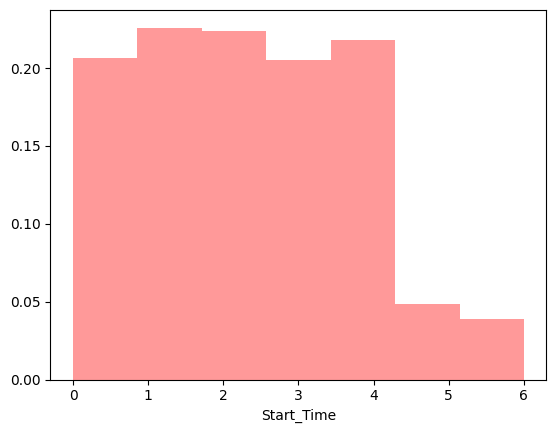

In [59]:
# Occurance of Accidents During a weak.
sns.distplot(Data.Start_Time.dt.dayofweek, bins=7, kde=False, norm_hist=True,color='red')



*   We can see there are more accidents in Weekdays then weekends.


<ipython-input-56-cc6522876543>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Data.Start_Time.dt.month, bins=7, kde=False, norm_hist=True, color='blue')


<Axes: xlabel='Start_Time'>

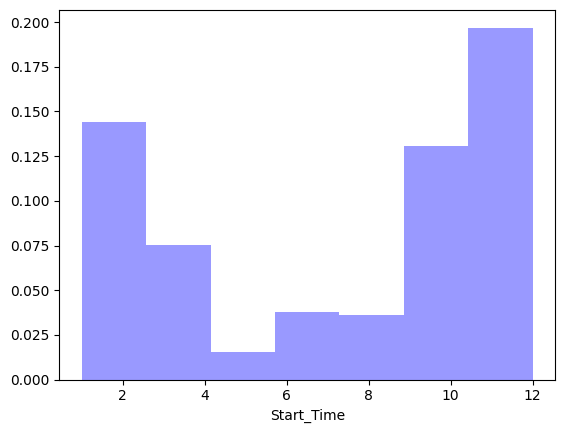

In [56]:
#  months wise accidents?
sns.distplot(Data.Start_Time.dt.month, bins=7, kde=False, norm_hist=True, color='blue')

There are some data missing from March to August in Dataset

In [27]:
Data.Start_Lat

,Start_Lat
0,39.852940
1,30.159246
2,41.586887
3,38.634579
4,32.930958
...,...
13496,41.473950
13497,35.301050
13498,35.300603
13499,26.137290


In [28]:
Data.Start_Lng

,Start_Lng
0,-75.461739
1,-95.510826
2,-93.806496
3,-90.186806
4,-97.641068
...,...
13496,-81.699310
13497,-80.855596
13498,-80.855455
13499,-80.217210


<Axes: xlabel='Start_Lng', ylabel='Start_Lat'>

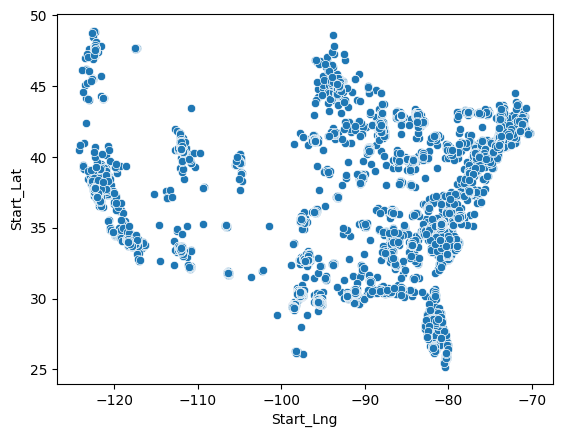

In [76]:
sns.scatterplot(x=Data.Start_Lng, y=Data.Start_Lat)

## Summary and Conclusion


Insights:
- No data from New York
- The number of accidents per city decreases exponentially
- There are more accidents in Morning hour(7 to 11 AM).
- There are more Accidents in Weekdays compare to Weekends
- Over 1100 cities have reported just one accident (need to investigate)
- There are missing data in the dataset between March - August.